# Phase 3 — Baseline modeling: predict real bank failure
### Thin walkthrough notebook — the real logic lives in `src/camel_sentinel/`

**What this notebook does**: trains a `RandomForestClassifier` on the six CAMEL ratios to predict the real, independent `failed` label, and evaluates it the way severe class imbalance requires (precision/recall/F1 on the minority class, not accuracy).

**Why `failed` and not the composite score**: the composite score is built *deterministically* from these same ratios (Phase 1) — training a model to reproduce it would just be re-deriving a formula the model already has direct access to. `failed` is a real, independent outcome, so predicting it is a genuine supervised-learning problem. See the module docstring in [`../src/camel_sentinel/models/baseline.py`](../src/camel_sentinel/models/baseline.py) for the full reasoning.

**How this connects onward**: the fitted model produced here is exactly what Phase 5 (XAI / SHAP) explains and Phase 6 (RAI) audits for fairness.

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd

SRC_PATH = str(Path("..").resolve() / "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from camel_sentinel.data import fdic_client
from camel_sentinel.features import camel_ratios
from camel_sentinel.models import baseline

warnings.filterwarnings("ignore")
print("Environment ready.")


Environment ready.


## 1. Load the CAMEL feature table

Same Phase 1 pipeline used in `00_dataset_research.ipynb` and `01_eda.ipynb`.

In [2]:
institutions, financials, failures, live_ok = fdic_client.try_live_pull()
if not live_ok:
    institutions, financials, failures = fdic_client.build_synthetic_sample()

camel = camel_ratios.score_composite(
    camel_ratios.build_camel_ratios(institutions, financials, failures)
)
camel.shape


(4658, 24)

## 2. Prepare features/target and split

`baseline.prepare_training_data()` selects the six CAMEL ratio columns and fills any gaps with the column median; `baseline.split_train_test()` does a *stratified* split so the rare `failed` class is represented proportionally in both train and test — see both docstrings for why each parameter is set the way it is.

In [3]:
X, y = baseline.prepare_training_data(camel)
X_train, X_test, y_train, y_test = baseline.split_train_test(X, y)
print(f"Train: {len(X_train)} rows ({y_train.mean():.1%} failed) | "
      f"Test: {len(X_test)} rows ({y_test.mean():.1%} failed)")


Train: 3493 rows (0.3% failed) | Test: 1165 rows (0.3% failed)


## 3. Train the baseline model

`class_weight="balanced"` (set inside `train_baseline_model`) is what keeps the model from taking the "always predict healthy" shortcut under this much class imbalance.

In [4]:
model = baseline.train_baseline_model(X_train, y_train)
print(model)


RandomForestClassifier(class_weight='balanced', max_depth=6, n_estimators=300,
                       random_state=42)


## 4. Evaluate — on the metrics that matter under imbalance

Read the `failed` row of the classification report, not the `accuracy` line — see "Class imbalance" in [`../docs/01_glossary.md`](../docs/01_glossary.md).

In [5]:
result = baseline.evaluate_model(model, X_test, y_test)


              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00      1161
      failed       0.00      0.00      0.00         4

    accuracy                           1.00      1165
   macro avg       0.50      0.50      0.50      1165
weighted avg       0.99      1.00      0.99      1165

Confusion matrix:
 [[1161    0]
 [   4    0]]


> **Reading a 0.00 "failed" row honestly**: with a real, corrected join (see [`../docs/02_data_sources.md`](../docs/02_data_sources.md)), one quarter's snapshot has only ~15 failed banks total across ~4,700 — split across train/test, the test set may hold as few as 3-4. No classifier can learn a reliable pattern from that few positive examples, no matter how it's tuned; a 0.00 precision/recall on `failed` here reflects **too little data, not a broken model or a bug in the pipeline**. This is precisely why the roadmap's Phase 4 (multi-quarter panel, pooling failures across many quarters into hundreds of positive examples instead of a handful) comes before any real tuning effort — tuning a model against 4 test examples would be tuning to noise.


## 5. Feature importance — which ratios does the model lean on?

A first, coarse answer to "why does the model say what it says" — Phase 5 replaces this with proper per-bank SHAP explanations, but the global ranking here is a useful sanity check: it should roughly track the ratios EDA (Phase 2) already flagged as most separating failed from healthy banks.

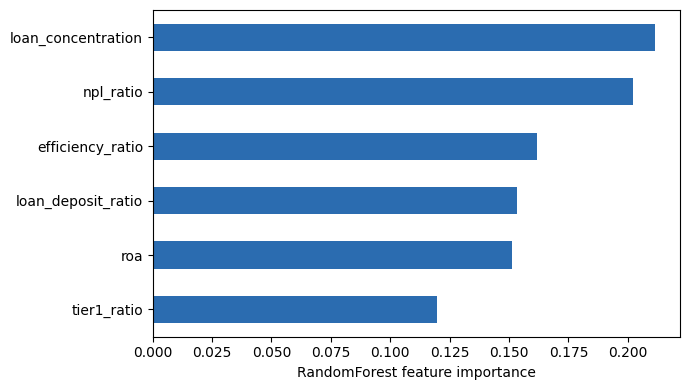

In [6]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color="#2b6cb0")
ax.set_xlabel("RandomForest feature importance")
plt.tight_layout()
plt.savefig("baseline_feature_importance.png", dpi=110)
plt.show()


## 6. Export the model

`registry.save_model()` writes the fitted model to the project's `models/` directory (gitignored — see `.gitignore`) via `joblib`, scikit-learn's own recommended serialization tool. This is the artifact a FastAPI backend will load in a later phase, instead of retraining on every request.


In [7]:
from camel_sentinel.models import registry

saved_path = registry.save_model(model)
print(f"Saved to {saved_path}")


Saved to C:\Users\raush\Downloads\AI-ML-Project-Afgan\Project\models\camel_baseline_model.joblib


## 6. What's next

This baseline is deliberately simple (shallow trees, one model family, one quarter of data) so Phase 4 (tuning) has clear room to improve: proper cross-validation on time (no look-ahead across quarters), imbalance techniques beyond class weighting, and a second model family to compare against. Phase 5 then explains *this* model (or its tuned successor) with SHAP, and Phase 6 audits it for fairness — see [`../docs/03_module_mapping.md`](../docs/03_module_mapping.md).